In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset, random_split
import torchvision.datasets as datasets
import os
%matplotlib inline

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [4]:
def load_data(Jd, l, num_conf, T, num_temps, batch_size, shuffle_opt, opt='train'):
    datasets = []
    for j in range(num_temps):
        path = f'data_spins/{Jd}_{opt}/spins_{l}_{T[j]}.npy'
        #if os.path.isfile(path):
        with open(path, 'rb') as f:
            x = np.load(f)   
        tensor_x = torch.Tensor(x).unsqueeze(1)
        path = f'data_spins/{Jd}_{opt}/answ_{l}_{T[j]}.npy'
        #if os.path.isfile(path):
        with open(path, 'rb') as f:
            y = np.load(f)
        tensor_y = torch.from_numpy(y).type(torch.float32)

        datasets.append(TensorDataset(tensor_x, tensor_y))


    dataset = torch.utils.data.ConcatDataset(datasets)

    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle_opt)

In [5]:
class Net(nn.Module):
    def __init__(self, l):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, 2)
        self.pool = nn.MaxPool2d(2, 2)
        self.act_hid = nn.ReLU()
        self.fc1 = nn.Linear(64*int(l/2-1)*int(l/2-1), 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool(x)
        x = self.act_hid(x)
        x = x.view(-1, 64*int(l/2-1)*int(l/2-1))
        x = self.fc1(x)
        x = self.act_hid(x)
        x = self.fc2(x)
        return x

In [6]:
def train(l, train_dataloader, num_epoch, criterion, batch_size):
    model = Net(l)
    optimizer = torch.optim.Adam(model.parameters(), lr=1.0e-4)
    act = nn.Sigmoid()

    for epoch in range(num_epoch):  
        running_loss = 0.0
        accuracy = 0.0
        pbar = tqdm(enumerate(train_dataloader), total=len(train_dataloader))
        for i, data in pbar:
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)  
            
            model.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            #outputs = act(outputs)

            outputs = outputs.squeeze(1) # к одной размерности с labels

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            accuracy += (batch_size - sum(abs(labels - act(outputs)))).float().mean()

            pbar.set_description(
                    f"Loss: {running_loss/((i+1)*batch_size)} "
                    f"Accuracy: {accuracy * 100  / ((i+1)*batch_size)}"
            )

    print('Training completed')
    return model

In [7]:
def testing(model, test_dataloader, criterion, batch_size):
    outp = []
    errors = []
    accuracy = 0.0
    act = nn.Sigmoid()
    with torch.no_grad():
        for i, data in enumerate(test_dataloader):
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)  
            model.to(device)
            outputs = model(inputs)
            #outputs = act(outputs)
            outputs = outputs.squeeze(1)
            outp.append(act(outputs).item())
            loss = criterion(outputs, labels)
            errors.append(loss.item())

            accuracy += (1 - sum(abs(labels - act(outputs)))).float().mean()

    print("Accuracy = {}".format(accuracy / len(test_dataloader)))
    return outp, errors

In [8]:
roots = [2.2691853142129728, 2.104982167992544, 1.932307699120554, 1.749339162933206, 1.5536238493280832, 1.34187327905057, 1.109960313758399, 0.8541630993606272, 0.5762735442012712, 0.2885386111960936, 0.03198372863548067]
jds = [0.0, -0.1, -0.2, -0.3, -0.4, -0.5, -0.6, -0.7, -0.8, -0.9, -1.0]
get_crit_T = dict(zip(jds, roots))

In [9]:
### training ###

def train_and_save(Jd, l, num_temps):
    num_conf_tr = 2048
    num_conf_ts = 512
    num_epoch = 1

    T_c = get_crit_T[Jd]
    T = np.linspace(0.03, 3.5, num_temps)
    T = np.round(T, 4)

    criterion = nn.BCEWithLogitsLoss()     

    train_dataloader = load_data(Jd, l, num_conf_tr, T, num_temps, batch_size=4, shuffle_opt=True, opt='train')
    print(f'Start training for L = {l}')
    model = train(l, train_dataloader, num_epoch, criterion, batch_size=4)

    PATH = f'models/{l}_{Jd}_{T[0]}_{T[-1]}_{num_temps}.pt'
    torch.save(model.state_dict(), PATH)

In [70]:
L = [60]
Jd = 0.0
num_temps = 50
for l in L:
    train_and_save(Jd, l, num_temps)

Start training for L = 60


Loss: 0.0052612094748893026 Accuracy: 99.00004577636719: 100%|██████████| 25600/25600 [19:34<00:00, 21.80it/s]


Training completed


In [13]:
### testing ###

def get_errs_outs(Jd, l, num_temps):
    T_c = get_crit_T[Jd]
    #T = np.linspace(T_c - 0.3, T_c + 0.3, num_temps)
    T = np.linspace(0.03, 3.5, num_temps)
    T = np.round(T, 4)

    num_conf_tr = 2048
    num_conf_ts = 512

    criterion = nn.BCEWithLogitsLoss()     
    
    print(f'Start testing for L = {l}, Jd = {Jd}')
    model = Net(l)
    #T_c_ = get_crit_T[0.0]
    #T_ = np.round(np.linspace(T_c_ - 0.3, T_c_ + 0.3, num_temps), 4)
    PATH = f'models/{l}_0.0_{T[0]}_{T[-1]}_{num_temps}.pt'

    model.load_state_dict(torch.load(PATH))
    model.eval()
    test_dataloader = load_data(Jd, l, num_conf_ts, T, num_temps, batch_size=1, shuffle_opt=False, opt='test')
    outp, errors = testing(model, test_dataloader, criterion, batch_size=1)
    return errors, outp

In [20]:
L = [60]
Jds = [-1.0]
num_temps = 50
for Jd in Jds: 
    for l in L:
        errs_outs = get_errs_outs(Jd, l, num_temps)
        np.save(f'data_errors/{Jd}_{l}_{num_temps}.npy', errs_outs[0])
        np.save(f'data_outputs/{Jd}_{l}_{num_temps}.npy', errs_outs[1])

Start testing for L = 60, Jd = -1.0


ValueError: Cannot load file containing pickled data when allow_pickle=False

In [10]:
def errs(errs):
    return np.array([sum(errs[i*512:(i+1)*512])/512 for i in range(num_temps)])

def stds_err(errs):
    return np.array([np.std(errs[i*512:(i+1)*512]) for i in range(num_temps)])

In [36]:
Jd = 0.0

num_temps = 50
T_c = get_crit_T[Jd]
T = np.linspace(0.03, 3.5, num_temps)

L = 10
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_10 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_10 = np.load(f)
    
L = 20
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_20 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_20 = np.load(f) 
    
L = 30
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_30 = np.load(f)
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_30 = np.load(f)
    
L = 40
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_40 = np.load(f)
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_40 = np.load(f)
    
'''L = 60
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_60 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_60 = np.load(f) 

L = 80
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_80 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_80 = np.load(f)'''

"L = 60\nwith open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    errs_60 = np.load(f) \nwith open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    outs_60 = np.load(f) \n\nL = 80\nwith open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    errs_80 = np.load(f) \nwith open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    outs_80 = np.load(f)"

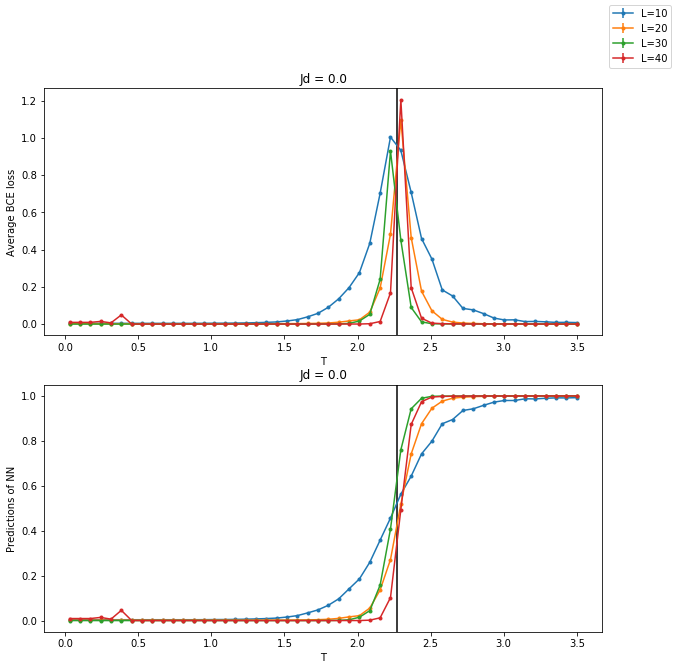

In [37]:
fig, ax = plt.subplots(2, 1, figsize=(10,10))

ax[0].errorbar(T, errs(errs_10), yerr=stds_err(errs_10)/1000, marker='.', label='L=10')
ax[0].errorbar(T, errs(errs_20), yerr=stds_err(errs_20)/1000, marker='.', label='L=20')
ax[0].errorbar(T, errs(errs_30), yerr=stds_err(errs_30)/1000, marker='.', label='L=30')
ax[0].errorbar(T, errs(errs_40), yerr=stds_err(errs_40)/1000, marker='.', label='L=40')
#ax[0].errorbar(T, errs(errs_60), yerr=stds_err(errs_60)/1000, marker='.', label='L=60')
#ax[0].errorbar(T, errs(errs_80), yerr=stds_err(errs_80)/1000, marker='.', label='L=80')

ax[1].errorbar(T, errs(outs_10), yerr=stds_err(outs_10)/1000, marker='.')
ax[1].errorbar(T, errs(outs_20), yerr=stds_err(outs_20)/1000, marker='.')
ax[1].errorbar(T, errs(outs_30), yerr=stds_err(outs_30)/1000, marker='.')
ax[1].errorbar(T, errs(outs_40), yerr=stds_err(outs_40)/1000, marker='.')
#ax[1].errorbar(T, errs(outs_60), yerr=stds_err(outs_60)/1000, marker='.')
#ax[1].errorbar(T, errs(outs_80), yerr=stds_err(outs_80)/1000, marker='.')

#plt.title('Jd = 0.0')
#plt.xlabel('T')
#plt.ylabel('Average BCE loss')

ax[0].axvline(x=T_c, color='black')
ax[1].axvline(x=T_c, color='black')

plt.setp(ax, xlabel='T')
ax[0].set_ylabel('Average BCE loss')
ax[1].set_ylabel('Predictions of NN')
plt.setp(ax, title='Jd = 0.0')
fig.legend()
#plt.xlim(T_c-0.1, T_c+0.1)
plt.show()

In [38]:
Jd = -0.3

num_temps = 50
T_c = get_crit_T[Jd]
T = np.linspace(0.03, 3.5, num_temps)

L = 10
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_10 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_10 = np.load(f)
    
L = 20
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_20 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_20 = np.load(f) 
    
L = 30
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_30 = np.load(f)
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_30 = np.load(f)
    
L = 40
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_40 = np.load(f)
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_40 = np.load(f)
    
'''L = 60
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_60 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_60 = np.load(f) 

L = 80
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_80 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_80 = np.load(f)'''

"L = 60\nwith open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    errs_60 = np.load(f) \nwith open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    outs_60 = np.load(f) \n\nL = 80\nwith open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    errs_80 = np.load(f) \nwith open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    outs_80 = np.load(f)"

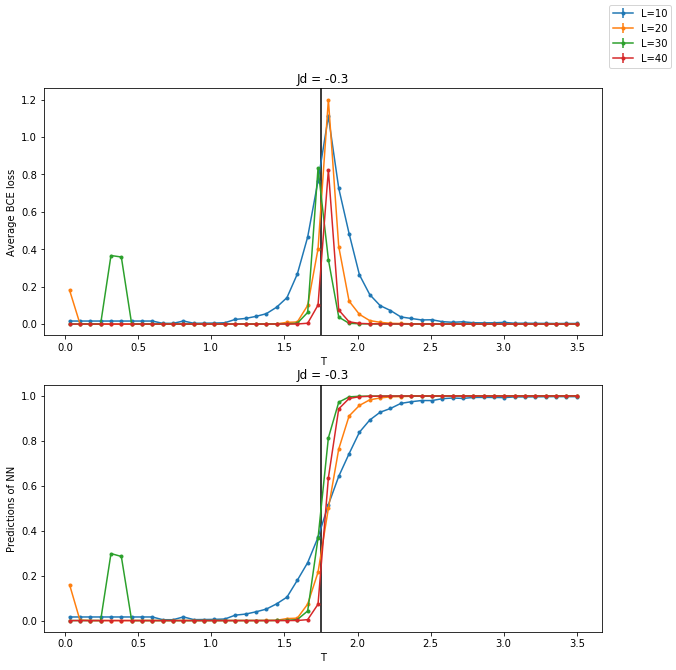

In [39]:
fig, ax = plt.subplots(2, 1, figsize=(10,10))

ax[0].errorbar(T, errs(errs_10), yerr=stds_err(errs_10)/1000, marker='.', label='L=10')
ax[0].errorbar(T, errs(errs_20), yerr=stds_err(errs_20)/1000, marker='.', label='L=20')
ax[0].errorbar(T, errs(errs_30), yerr=stds_err(errs_30)/1000, marker='.', label='L=30')
ax[0].errorbar(T, errs(errs_40), yerr=stds_err(errs_40)/1000, marker='.', label='L=40')
#ax[0].errorbar(T, errs(errs_60), yerr=stds_err(errs_60)/1000, marker='.', label='L=60')
#ax[0].errorbar(T, errs(errs_80), yerr=stds_err(errs_80)/1000, marker='.', label='L=80')

ax[1].errorbar(T, errs(outs_10), yerr=stds_err(outs_10)/1000, marker='.')
ax[1].errorbar(T, errs(outs_20), yerr=stds_err(outs_20)/1000, marker='.')
ax[1].errorbar(T, errs(outs_30), yerr=stds_err(outs_30)/1000, marker='.')
ax[1].errorbar(T, errs(outs_40), yerr=stds_err(outs_40)/1000, marker='.')
#ax[1].errorbar(T, errs(outs_60), yerr=stds_err(outs_60)/1000, marker='.')
#ax[1].errorbar(T, errs(outs_80), yerr=stds_err(outs_80)/1000, marker='.')

#plt.title('Jd = 0.0')
#plt.xlabel('T')
#plt.ylabel('Average BCE loss')

ax[0].axvline(x=T_c, color='black')
ax[1].axvline(x=T_c, color='black')

plt.setp(ax, xlabel='T')
ax[0].set_ylabel('Average BCE loss')
ax[1].set_ylabel('Predictions of NN')
plt.setp(ax, title='Jd = -0.3')
fig.legend()
#plt.xlim(T_c-0.1, T_c+0.1)
plt.show()

In [40]:
Jd = -0.5

num_temps = 50
T_c = get_crit_T[Jd]
T = np.linspace(0.03, 3.5, num_temps)

L = 10
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_10 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_10 = np.load(f)
    
L = 20
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_20 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_20 = np.load(f) 
    
L = 30
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_30 = np.load(f)
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_30 = np.load(f)
    
L = 40
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_40 = np.load(f)
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_40 = np.load(f)
    
'''L = 60
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_60 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_60 = np.load(f) 

L = 80
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_80 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_80 = np.load(f)'''

"L = 60\nwith open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    errs_60 = np.load(f) \nwith open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    outs_60 = np.load(f) \n\nL = 80\nwith open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    errs_80 = np.load(f) \nwith open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    outs_80 = np.load(f)"

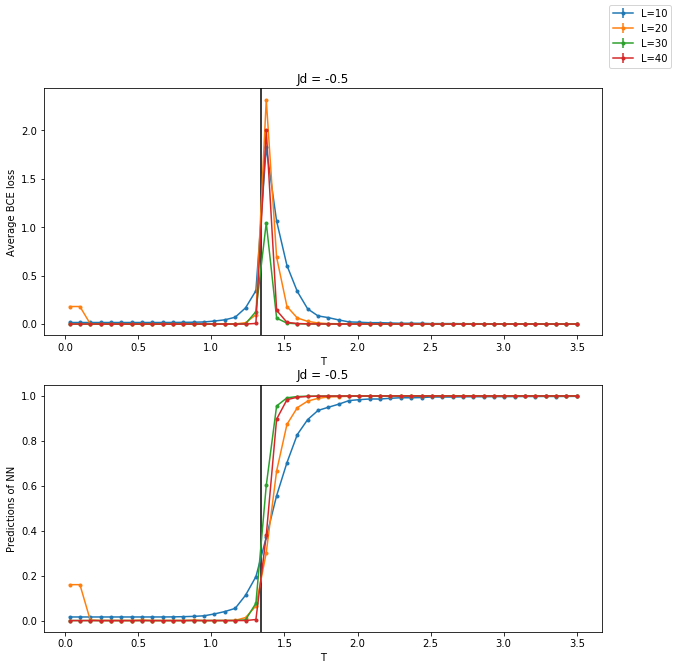

In [41]:
fig, ax = plt.subplots(2, 1, figsize=(10,10))

ax[0].errorbar(T, errs(errs_10), yerr=stds_err(errs_10)/1000, marker='.', label='L=10')
ax[0].errorbar(T, errs(errs_20), yerr=stds_err(errs_20)/1000, marker='.', label='L=20')
ax[0].errorbar(T, errs(errs_30), yerr=stds_err(errs_30)/1000, marker='.', label='L=30')
ax[0].errorbar(T, errs(errs_40), yerr=stds_err(errs_40)/1000, marker='.', label='L=40')
#ax[0].errorbar(T, errs(errs_60), yerr=stds_err(errs_60)/1000, marker='.', label='L=60')
#ax[0].errorbar(T, errs(errs_80), yerr=stds_err(errs_80)/1000, marker='.', label='L=80')

ax[1].errorbar(T, errs(outs_10), yerr=stds_err(outs_10)/1000, marker='.')
ax[1].errorbar(T, errs(outs_20), yerr=stds_err(outs_20)/1000, marker='.')
ax[1].errorbar(T, errs(outs_30), yerr=stds_err(outs_30)/1000, marker='.')
ax[1].errorbar(T, errs(outs_40), yerr=stds_err(outs_40)/1000, marker='.')
#ax[1].errorbar(T, errs(outs_60), yerr=stds_err(outs_60)/1000, marker='.')
#ax[1].errorbar(T, errs(outs_80), yerr=stds_err(outs_80)/1000, marker='.')

#plt.title('Jd = 0.0')
#plt.xlabel('T')
#plt.ylabel('Average BCE loss')

ax[0].axvline(x=T_c, color='black')
ax[1].axvline(x=T_c, color='black')

plt.setp(ax, xlabel='T')
ax[0].set_ylabel('Average BCE loss')
ax[1].set_ylabel('Predictions of NN')
plt.setp(ax, title='Jd = -0.5')
fig.legend()
#plt.xlim(T_c-0.1, T_c+0.1)
plt.show()

In [51]:
Jd = -0.7

num_temps = 50
T_c = get_crit_T[Jd]
T = np.linspace(0.03, 3.5, num_temps)

L = 10
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_10 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_10 = np.load(f)
    
L = 20
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_20 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_20 = np.load(f) 
    
L = 30
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_30 = np.load(f)
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_30 = np.load(f)
    
L = 40
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_40 = np.load(f)
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_40 = np.load(f)
    
'''L = 60
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_60 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_60 = np.load(f) 

L = 80
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_80 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_80 = np.load(f)'''

"L = 60\nwith open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    errs_60 = np.load(f) \nwith open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    outs_60 = np.load(f) \n\nL = 80\nwith open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    errs_80 = np.load(f) \nwith open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    outs_80 = np.load(f)"

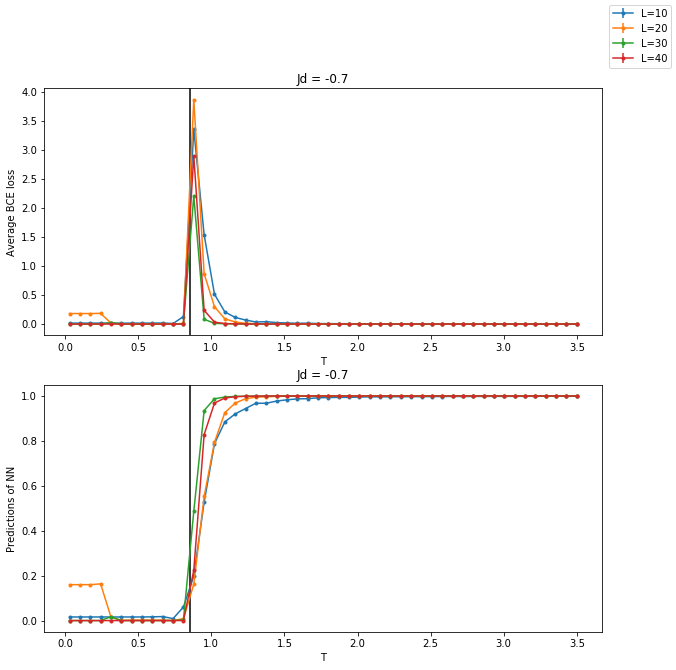

In [53]:
fig, ax = plt.subplots(2, 1, figsize=(10,10))

ax[0].errorbar(T, errs(errs_10), yerr=stds_err(errs_10)/1000, marker='.', label='L=10')
ax[0].errorbar(T, errs(errs_20), yerr=stds_err(errs_20)/1000, marker='.', label='L=20')
ax[0].errorbar(T, errs(errs_30), yerr=stds_err(errs_30)/1000, marker='.', label='L=30')
ax[0].errorbar(T, errs(errs_40), yerr=stds_err(errs_40)/1000, marker='.', label='L=40')
#ax[0].errorbar(T, errs(errs_60), yerr=stds_err(errs_60)/1000, marker='.', label='L=60')
#ax[0].errorbar(T, errs(errs_80), yerr=stds_err(errs_80)/1000, marker='.', label='L=80')

ax[1].errorbar(T, errs(outs_10), yerr=stds_err(outs_10)/1000, marker='.')
ax[1].errorbar(T, errs(outs_20), yerr=stds_err(outs_20)/1000, marker='.')
ax[1].errorbar(T, errs(outs_30), yerr=stds_err(outs_30)/1000, marker='.')
ax[1].errorbar(T, errs(outs_40), yerr=stds_err(outs_40)/1000, marker='.')
#ax[1].errorbar(T, errs(outs_60), yerr=stds_err(outs_60)/1000, marker='.')
#ax[1].errorbar(T, errs(outs_80), yerr=stds_err(outs_80)/1000, marker='.')

#plt.title('Jd = 0.0')
#plt.xlabel('T')
#plt.ylabel('Average BCE loss')

ax[0].axvline(x=T_c, color='black')
ax[1].axvline(x=T_c, color='black')

plt.setp(ax, xlabel='T')
ax[0].set_ylabel('Average BCE loss')
ax[1].set_ylabel('Predictions of NN')
plt.setp(ax, title='Jd = -0.7')
fig.legend()
#plt.xlim(T_c-0.3, T_c+0.3)
plt.show()

In [44]:
Jd = -0.9

num_temps = 50
T_c = get_crit_T[Jd]
T = np.linspace(0.03, 3.5, num_temps)

L = 10
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_10 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_10 = np.load(f)
    
L = 20
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_20 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_20 = np.load(f) 
    
L = 30
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_30 = np.load(f)
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_30 = np.load(f)
    
L = 40
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_40 = np.load(f)
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_40 = np.load(f)
    
'''L = 60
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_60 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_60 = np.load(f) 

L = 80
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_80 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_80 = np.load(f)'''

"L = 60\nwith open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    errs_60 = np.load(f) \nwith open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    outs_60 = np.load(f) \n\nL = 80\nwith open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    errs_80 = np.load(f) \nwith open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    outs_80 = np.load(f)"

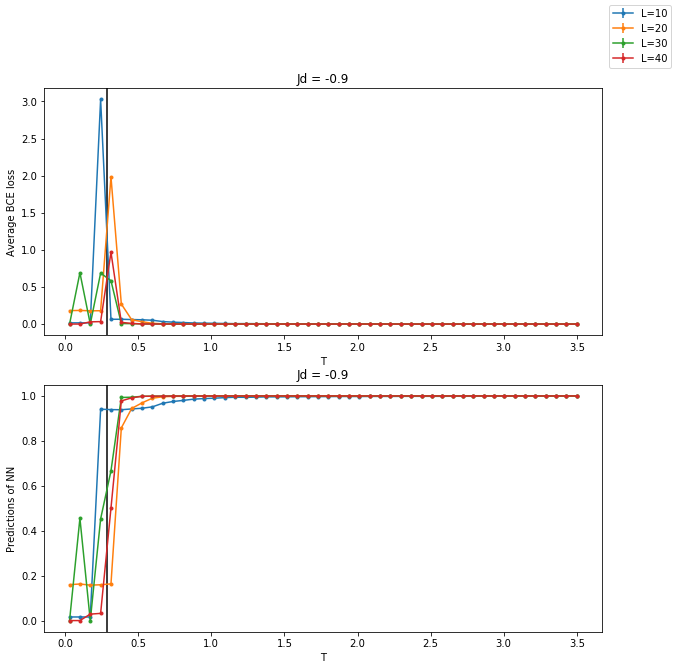

In [45]:
fig, ax = plt.subplots(2, 1, figsize=(10,10))

ax[0].errorbar(T, errs(errs_10), yerr=stds_err(errs_10)/1000, marker='.', label='L=10')
ax[0].errorbar(T, errs(errs_20), yerr=stds_err(errs_20)/1000, marker='.', label='L=20')
ax[0].errorbar(T, errs(errs_30), yerr=stds_err(errs_30)/1000, marker='.', label='L=30')
ax[0].errorbar(T, errs(errs_40), yerr=stds_err(errs_40)/1000, marker='.', label='L=40')
#ax[0].errorbar(T, errs(errs_60), yerr=stds_err(errs_60)/1000, marker='.', label='L=60')
#ax[0].errorbar(T, errs(errs_80), yerr=stds_err(errs_80)/1000, marker='.', label='L=80')

ax[1].errorbar(T, errs(outs_10), yerr=stds_err(outs_10)/1000, marker='.')
ax[1].errorbar(T, errs(outs_20), yerr=stds_err(outs_20)/1000, marker='.')
ax[1].errorbar(T, errs(outs_30), yerr=stds_err(outs_30)/1000, marker='.')
ax[1].errorbar(T, errs(outs_40), yerr=stds_err(outs_40)/1000, marker='.')
#ax[1].errorbar(T, errs(outs_60), yerr=stds_err(outs_60)/1000, marker='.')
#ax[1].errorbar(T, errs(outs_80), yerr=stds_err(outs_80)/1000, marker='.')

#plt.title('Jd = 0.0')
#plt.xlabel('T')
#plt.ylabel('Average BCE loss')

ax[0].axvline(x=T_c, color='black')
ax[1].axvline(x=T_c, color='black')

plt.setp(ax, xlabel='T')
ax[0].set_ylabel('Average BCE loss')
ax[1].set_ylabel('Predictions of NN')
plt.setp(ax, title='Jd = -0.9')
fig.legend()
#plt.xlim(T_c-0.1, T_c+0.1)
plt.show()

In [46]:
Jd = -1.0

num_temps = 50
T_c = get_crit_T[Jd]
T = np.linspace(0.03, 3.5, num_temps)

L = 10
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_10 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_10 = np.load(f)
    
L = 20
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_20 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_20 = np.load(f) 
    
L = 30
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_30 = np.load(f)
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_30 = np.load(f)
    
L = 40
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_40 = np.load(f)
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_40 = np.load(f)
    
'''L = 60
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_60 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_60 = np.load(f) 

L = 80
with open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    errs_80 = np.load(f) 
with open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:
    outs_80 = np.load(f)'''

"L = 60\nwith open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    errs_60 = np.load(f) \nwith open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    outs_60 = np.load(f) \n\nL = 80\nwith open(f'data_errors/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    errs_80 = np.load(f) \nwith open(f'data_outputs/{Jd}_{L}_{num_temps}.npy', 'rb') as f:\n    outs_80 = np.load(f)"

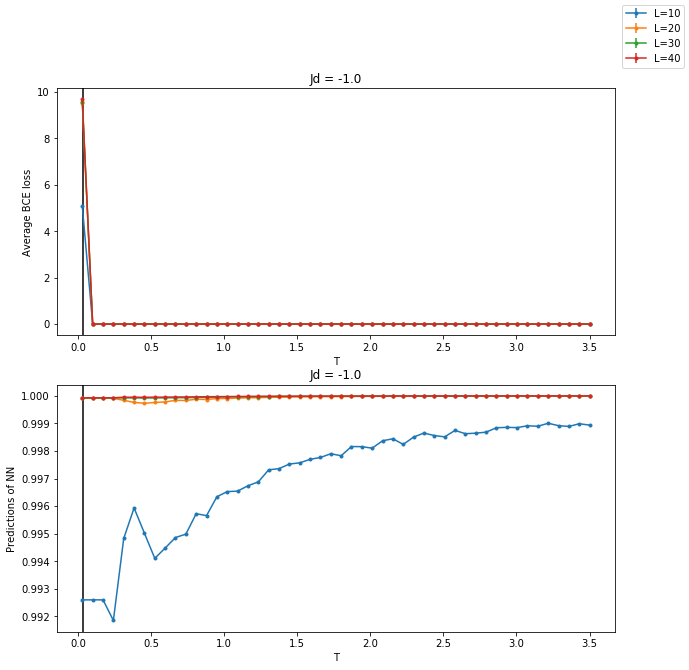

In [47]:
fig, ax = plt.subplots(2, 1, figsize=(10,10))

ax[0].errorbar(T, errs(errs_10), yerr=stds_err(errs_10)/1000, marker='.', label='L=10')
ax[0].errorbar(T, errs(errs_20), yerr=stds_err(errs_20)/1000, marker='.', label='L=20')
ax[0].errorbar(T, errs(errs_30), yerr=stds_err(errs_30)/1000, marker='.', label='L=30')
ax[0].errorbar(T, errs(errs_40), yerr=stds_err(errs_40)/1000, marker='.', label='L=40')
#ax[0].errorbar(T, errs(errs_60), yerr=stds_err(errs_60)/1000, marker='.', label='L=60')
#ax[0].errorbar(T, errs(errs_80), yerr=stds_err(errs_80)/1000, marker='.', label='L=80')

ax[1].errorbar(T, errs(outs_10), yerr=stds_err(outs_10)/1000, marker='.')
ax[1].errorbar(T, errs(outs_20), yerr=stds_err(outs_20)/1000, marker='.')
ax[1].errorbar(T, errs(outs_30), yerr=stds_err(outs_30)/1000, marker='.')
ax[1].errorbar(T, errs(outs_40), yerr=stds_err(outs_40)/1000, marker='.')
#ax[1].errorbar(T, errs(outs_60), yerr=stds_err(outs_60)/1000, marker='.')
#ax[1].errorbar(T, errs(outs_80), yerr=stds_err(outs_80)/1000, marker='.')

#plt.title('Jd = 0.0')
#plt.xlabel('T')
#plt.ylabel('Average BCE loss')

ax[0].axvline(x=T_c, color='black')
ax[1].axvline(x=T_c, color='black')

plt.setp(ax, xlabel='T')
ax[0].set_ylabel('Average BCE loss')
ax[1].set_ylabel('Predictions of NN')
plt.setp(ax, title='Jd = -1.0')
fig.legend()
#plt.xlim(T_c-0.1, T_c+0.1)
plt.show()